In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
df = pd.read_csv('taylor_swift_lyrics.csv', encoding='latin-1')
print("📊 Shape:", df.shape)
print("📋 Columns:", df.columns.tolist())
df.head()

📊 Shape: (4862, 7)
📋 Columns: ['artist', 'album', 'track_title', 'track_n', 'lyric', 'line', 'year']


,artist,album,track_title,track_n,lyric,line,year
0,Taylor Swift,Taylor Swift,Tim McGraw,1,He said the way my blue eyes shined,1,2006
1,Taylor Swift,Taylor Swift,Tim McGraw,1,Put those Georgia stars to shame that night,2,2006
2,Taylor Swift,Taylor Swift,Tim McGraw,1,"I said, ""That's a lie""",3,2006
3,Taylor Swift,Taylor Swift,Tim McGraw,1,Just a boy in a Chevy truck,4,2006
4,Taylor Swift,Taylor Swift,Tim McGraw,1,That had a tendency of gettin' stuck,5,2006


In [5]:
print("🎵 Albums:", df['album'].unique())
print("📅 Years:", sorted(df['year'].unique()))
print("🎤 Total lyrics lines:", len(df))
print("🎵 Total songs:", df['track_title'].nunique())

🎵 Albums: ['Taylor Swift' 'Fearless' 'Speak Now' 'Red' '1989' 'reputation']
📅 Years: [np.int64(2006), np.int64(2008), np.int64(2010), np.int64(2012), np.int64(2014), np.int64(2017)]
🎤 Total lyrics lines: 4862
🎵 Total songs: 94


In [6]:
df.head()

,artist,album,track_title,track_n,lyric,line,year
0,Taylor Swift,Taylor Swift,Tim McGraw,1,He said the way my blue eyes shined,1,2006
1,Taylor Swift,Taylor Swift,Tim McGraw,1,Put those Georgia stars to shame that night,2,2006
2,Taylor Swift,Taylor Swift,Tim McGraw,1,"I said, ""That's a lie""",3,2006
3,Taylor Swift,Taylor Swift,Tim McGraw,1,Just a boy in a Chevy truck,4,2006
4,Taylor Swift,Taylor Swift,Tim McGraw,1,That had a tendency of gettin' stuck,5,2006


In [9]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

all_lyrics = ' '.join(df['lyric'].dropna().tolist())
corpus = clean_text(all_lyrics)

print(f"📝 Total characters : {len(corpus)}")
print(f"📝 Sample : {corpus[:300]}")

📝 Total characters : 167705
📝 Sample : he said the way my blue eyes shined put those georgia stars to shame that night i said thats a lie just a boy in a chevy truck that had a tendency of gettin stuck on backroads at night and i was right there beside him all summer long and then the time we woke up to find that summer gone but when you


In [10]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print(f"🔤 Vocabulary size : {total_words}")

🔤 Vocabulary size : 2381


In [11]:
input_sequences = []

for line in df['lyric'].dropna():
    line_clean = clean_text(line)
    token_list = tokenizer.texts_to_sequences([line_clean])[0]
    
    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

print(f"📊 Total sequences : {len(input_sequences)}")

📊 Total sequences : 30344


In [13]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=total_words)

print(f"✅ X shape : {X.shape}")
print(f"✅ y shape : {y.shape}")

✅ X shape : (30344, 19)
✅ y shape : (30344, 2381)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical        # ← manquait ici
from tensorflow.keras.callbacks import EarlyStopping

print("✅ Tous les imports OK !")

✅ Tous les imports OK !


In [15]:
model = Sequential([
    Embedding(input_dim=total_words, output_dim=100, input_length=SEQ_LENGTH-1),
    LSTM(150, return_sequences=True),
    Dropout(0.2),
    LSTM(100),
    Dropout(0.2),
    Dense(total_words, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X, y,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Entraînement terminé !")

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 47s 79ms/step - accuracy: 0.0467 - loss: 6.3697
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.0522 - loss: 5.7705
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.0602 - loss: 5.5097
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.0788 - loss: 5.2641
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.1018 - loss: 5.0815
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.1164 - loss: 4.8972
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.1235 - loss: 4.7704
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.1426 - loss: 4.6186
Epoch 9/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.1499 - loss: 4.5185
Epoch 10/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.1618 - loss: 4.4203
Epoch 11/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - accuracy: 0.1738 - loss: 4.2983
Epoch 12/50
475/475 ━━━━━━━━━

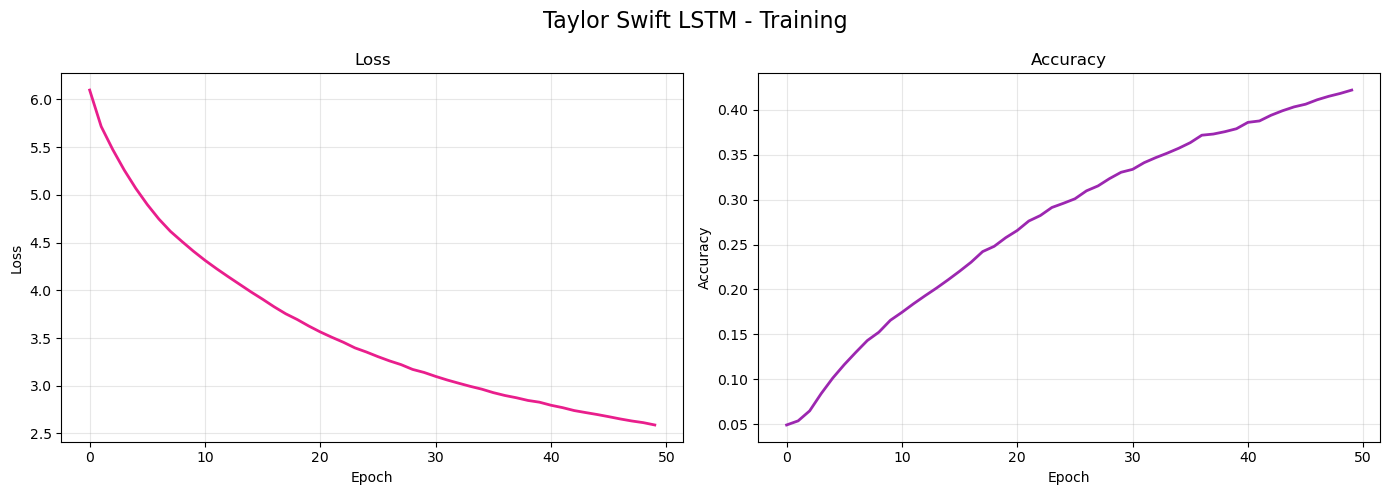

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], color='#e91e8c', linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], color='#9c27b0', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Taylor Swift LSTM - Training', fontsize=16)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [18]:
def generate_lyrics(seed_text, next_words=30, temperature=0.8):
    result = seed_text
    
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences(
            [token_list],
            maxlen=SEQ_LENGTH-1,
            padding='pre'
        )
        
        predictions = model.predict(token_list, verbose=0)[0]
        predictions = np.log(predictions + 1e-10) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))
        
        predicted_index = np.random.choice(len(predictions), p=predictions)
        output_word = tokenizer.index_word.get(predicted_index, "")
        
        seed_text += " " + output_word
        result += " " + output_word
    
    return result


seeds = [
    "i knew you were trouble",
    "we are never getting back together",
    "shake it off",
    "long live all the mountains"
]

print("=" * 60)
print("🎵 GENERATED TAYLOR SWIFT LYRICS")
print("=" * 60)

for seed in seeds:
    print(f"\n🎤 Seed : '{seed}'")
    print("-" * 40)
    print(generate_lyrics(seed, next_words=25, temperature=0.8))

🎵 GENERATED TAYLOR SWIFT LYRICS

🎤 Seed : 'i knew you were trouble'
----------------------------------------
i knew you were trouble away the story of us honey you know you better now i just know that right what you want call it what you want it

🎤 Seed : 'we are never getting back together'
----------------------------------------
we are never getting back together down around break here as a daydream and like i know with my names at my whole scene and know now this is so mine

🎤 Seed : 'shake it off'
----------------------------------------
shake it off i shake it off i shake it off i shake it off i shake it off i shake it off i shake it off i

🎤 Seed : 'long live all the mountains'
----------------------------------------
long live all the mountains i watched you think that its you out of the woods yet are we in your head on that they broke up with the door


In [20]:
print("🌡️ Effet de la température sur la génération :\n")

for temp in [0.5, 1.0, 1.5]:
    print(f"Temperature = {temp} :")
    result = generate_lyrics("shake it off", next_words=20, temperature=temp)
    print(f"  → {result}\n")

🌡️ Effet de la température sur la génération :

Temperature = 0.5 :
  → shake it off i shake it off i shake it off i shake it off i shake it off i shake it off

Temperature = 1.0 :
  → shake it off i shake it off this lucky big end game end game love you like it honey all night to roll

Temperature = 1.5 :
  → shake it off i shake it off i x no too skin that no mad close wide tired of his hesaidshesaid out of



In [25]:
model.save('taylor_swift_lstm.keras')
print("✅ Modèle sauvegardé en format .keras !")

✅ Modèle sauvegardé en format .keras !
